In [1]:
# Libraries import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

#chart style set
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize']=(12,6)

In [6]:
#PostgreSQL Connection
engine = create_engine('postgresql://munju@localhost:5432/olist_ecommerce')

#test connection
with engine.connect() as conn:
    print("Database connected successfully!")

Database connected successfully!


In [8]:
# সব tables DataFrame এ load করো
orders = pd.read_sql("SELECT * FROM orders", engine)
order_items = pd.read_sql("SELECT * FROM order_items", engine)
order_payments = pd.read_sql("SELECT * FROM order_payments", engine)
customers = pd.read_sql("SELECT * FROM customers", engine)
products = pd.read_sql("SELECT * FROM products", engine)
sellers = pd.read_sql("SELECT * FROM sellers", engine)
reviews = pd.read_sql("SELECT * FROM order_reviews", engine)
translation = pd.read_sql("SELECT * FROM product_category_translation", engine)

print("All tables loaded!")
print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Payments: {order_payments.shape}")
print(f"Customers: {customers.shape}")

All tables loaded!
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Customers: (99441, 5)


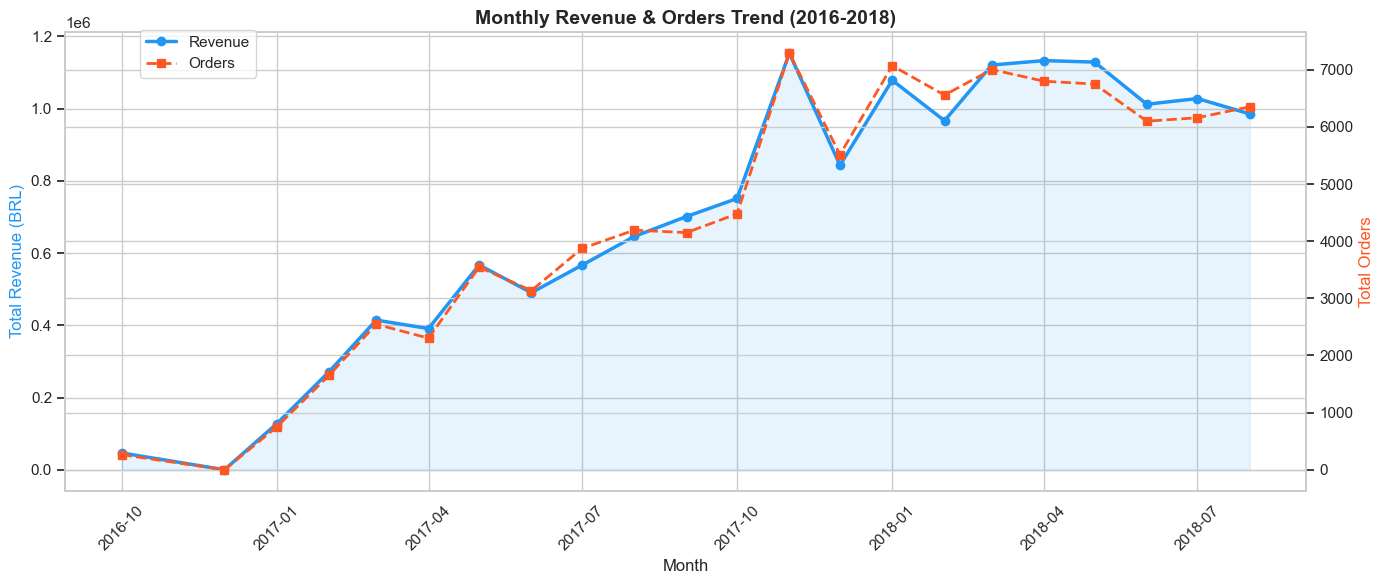

Chart saved!


In [9]:
# Monthly Revenue Data
monthly_revenue = pd.read_sql("""
    SELECT 
        DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
        ROUND(SUM(p.payment_value)::NUMERIC, 2) AS total_revenue,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM orders o
    JOIN order_payments p ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY DATE_TRUNC('month', o.order_purchase_timestamp)
    ORDER BY month
""", engine)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Revenue line
ax1.plot(monthly_revenue['month'], monthly_revenue['total_revenue'], 
         color='#2196F3', linewidth=2.5, marker='o', label='Revenue')
ax1.fill_between(monthly_revenue['month'], monthly_revenue['total_revenue'], 
                  alpha=0.1, color='#2196F3')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Revenue (BRL)', fontsize=12, color='#2196F3')
ax1.tick_params(axis='x', rotation=45)

# Orders line (second y-axis)
ax2 = ax1.twinx()
ax2.plot(monthly_revenue['month'], monthly_revenue['total_orders'], 
         color='#FF5722', linewidth=2, linestyle='--', marker='s', label='Orders')
ax2.set_ylabel('Total Orders', fontsize=12, color='#FF5722')

# Title & Legend
plt.title('Monthly Revenue & Orders Trend (2016-2018)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

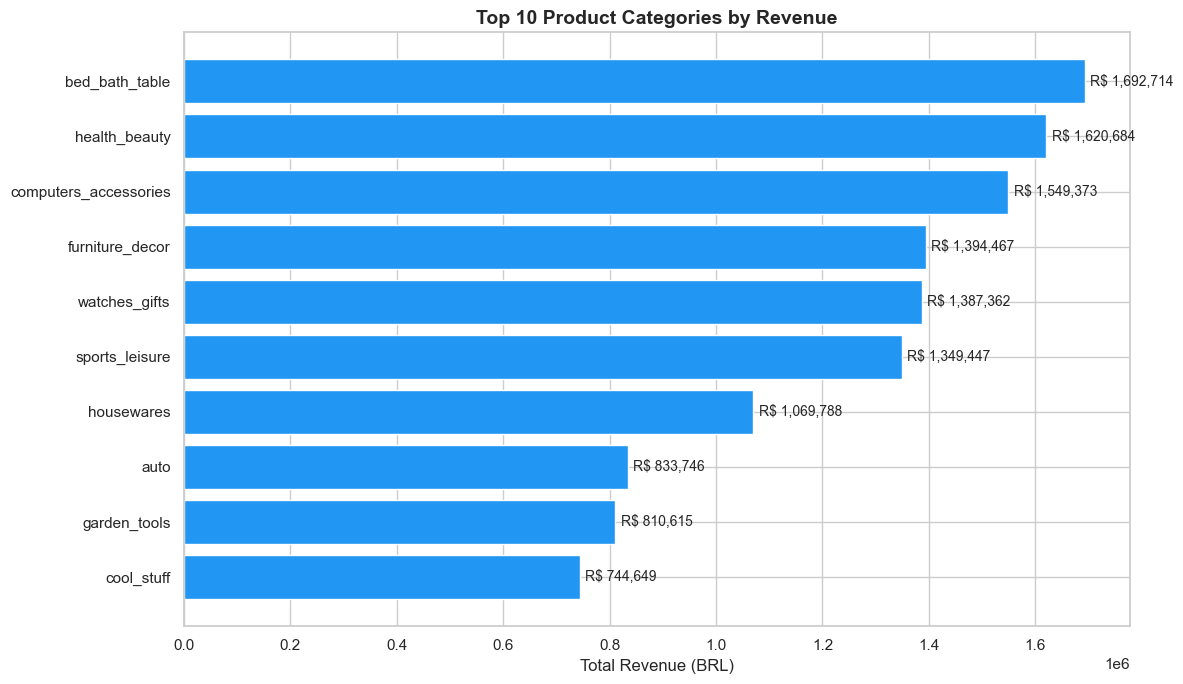

Chart saved!


In [10]:
# Top Categories Data
top_categories = pd.read_sql("""
    SELECT 
        COALESCE(t.product_category_name_english, p.product_category_name, 'Unknown') AS category,
        ROUND(SUM(pay.payment_value)::NUMERIC, 2) AS total_revenue
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    JOIN order_payments pay ON oi.order_id = pay.order_id
    LEFT JOIN product_category_translation t ON p.product_category_name = t.product_category_name
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY COALESCE(t.product_category_name_english, p.product_category_name, 'Unknown')
    ORDER BY total_revenue DESC
    LIMIT 10
""", engine)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_categories['category'], top_categories['total_revenue'],
               color='#2196F3', edgecolor='white')

# Value labels
for bar, val in zip(bars, top_categories['total_revenue']):
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'R$ {val:,.0f}', va='center', fontsize=10)

ax.set_xlabel('Total Revenue (BRL)', fontsize=12)
ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

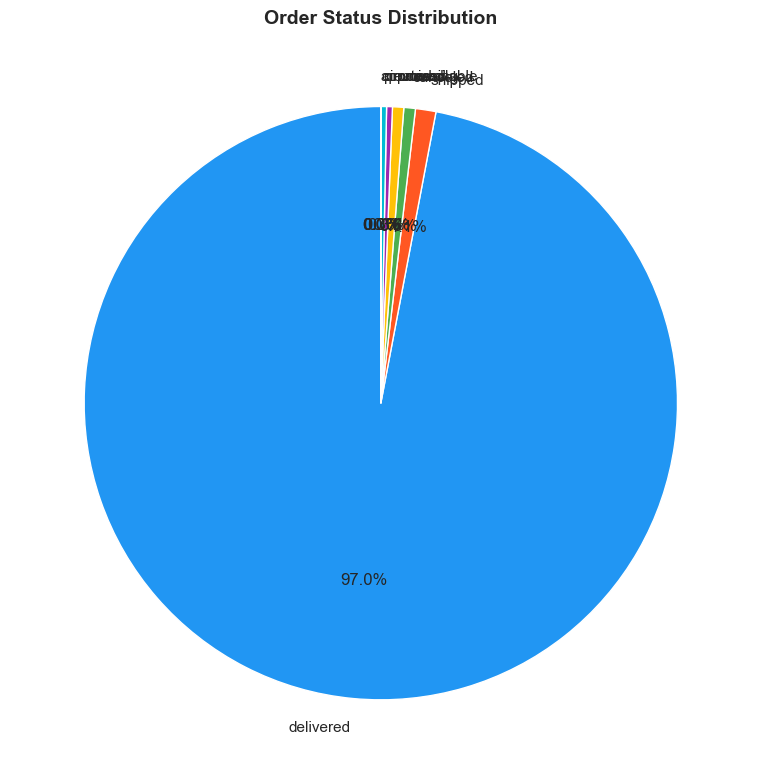

Chart 3 saved!


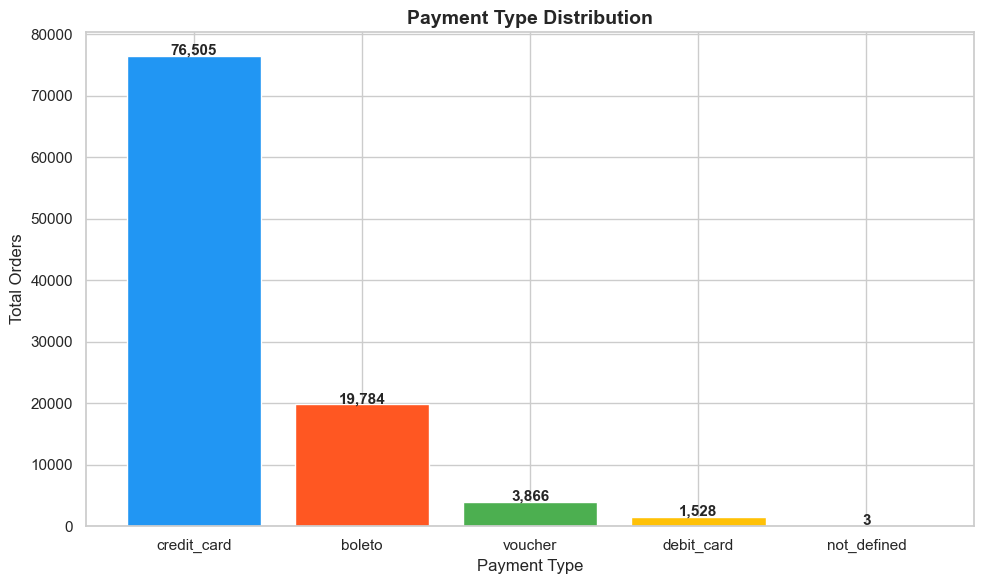

Chart 4 saved!


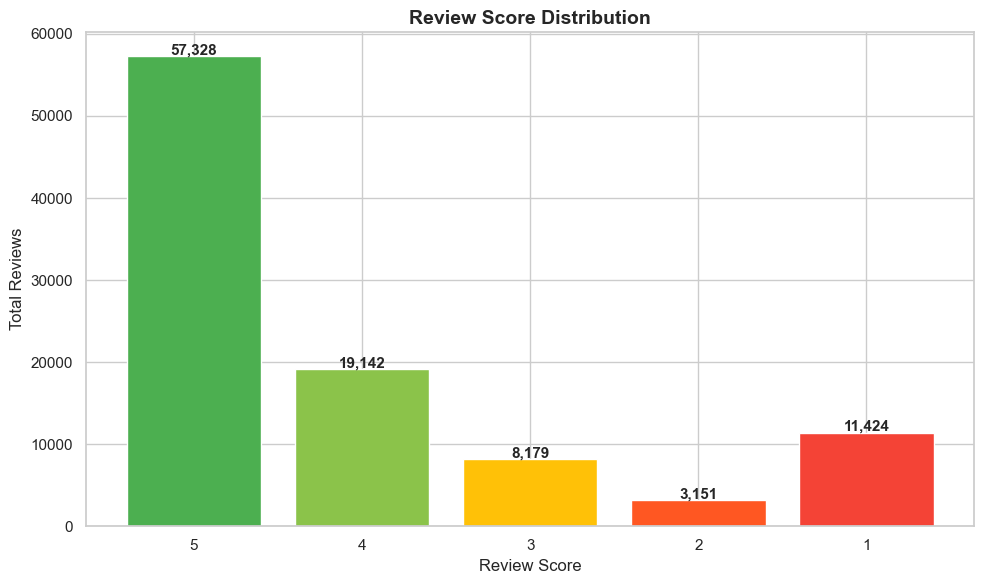

Chart 5 saved!


In [11]:
# ── Chart 3: Order Status Pie Chart ──
order_status = pd.read_sql("""
    SELECT order_status, COUNT(order_id) AS total_orders
    FROM orders
    GROUP BY order_status
    ORDER BY total_orders DESC
""", engine)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(order_status['total_orders'], labels=order_status['order_status'],
       autopct='%1.1f%%', startangle=90,
       colors=['#2196F3','#FF5722','#4CAF50','#FFC107','#9C27B0','#00BCD4','#FF9800','#795548'])
ax.set_title('Order Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('order_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

# ── Chart 4: Payment Type Bar Chart ──
payments = pd.read_sql("""
    SELECT payment_type,
           COUNT(DISTINCT order_id) AS total_orders,
           ROUND(SUM(payment_value)::NUMERIC, 2) AS total_revenue
    FROM order_payments
    GROUP BY payment_type
    ORDER BY total_orders DESC
""", engine)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(payments['payment_type'], payments['total_orders'],
              color=['#2196F3','#FF5722','#4CAF50','#FFC107','#9C27B0'])
for bar, val in zip(bars, payments['total_orders']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Payment Type', fontsize=12)
ax.set_ylabel('Total Orders', fontsize=12)
ax.set_title('Payment Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('payment_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

# ── Chart 5: Review Score Bar Chart ──
reviews_data = pd.read_sql("""
    SELECT review_score, COUNT(review_id) AS total_reviews
    FROM order_reviews
    GROUP BY review_score
    ORDER BY review_score DESC
""", engine)

colors = ['#4CAF50','#8BC34A','#FFC107','#FF5722','#F44336']
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(reviews_data['review_score'].astype(str),
              reviews_data['total_reviews'], color=colors)
for bar, val in zip(bars, reviews_data['total_reviews']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Review Score', fontsize=12)
ax.set_ylabel('Total Reviews', fontsize=12)
ax.set_title('Review Score Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('review_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")